Accuracy:  0.47115384615384615
              precision    recall  f1-score   support

           0       0.43      0.46      0.44       100
           1       0.35      0.08      0.13        86
           2       0.51      0.75      0.60       126

    accuracy                           0.47       312
   macro avg       0.43      0.43      0.39       312
weighted avg       0.44      0.47      0.42       312



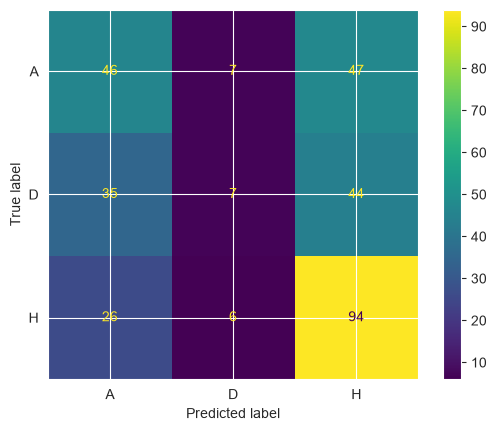

                Feature  Importance
3  AwayShotsOnTargetAvg    0.137874
0          HomeGoalsAvg    0.137631
2  HomeShotsOnTargetAvg    0.135848
4        HomeCornersAvg    0.125008
7          AwayFoulsAvg    0.118524
5        AwayCornersAvg    0.117819
6          HomeFoulsAvg    0.117338
1          AwayGoalsAvg    0.109958


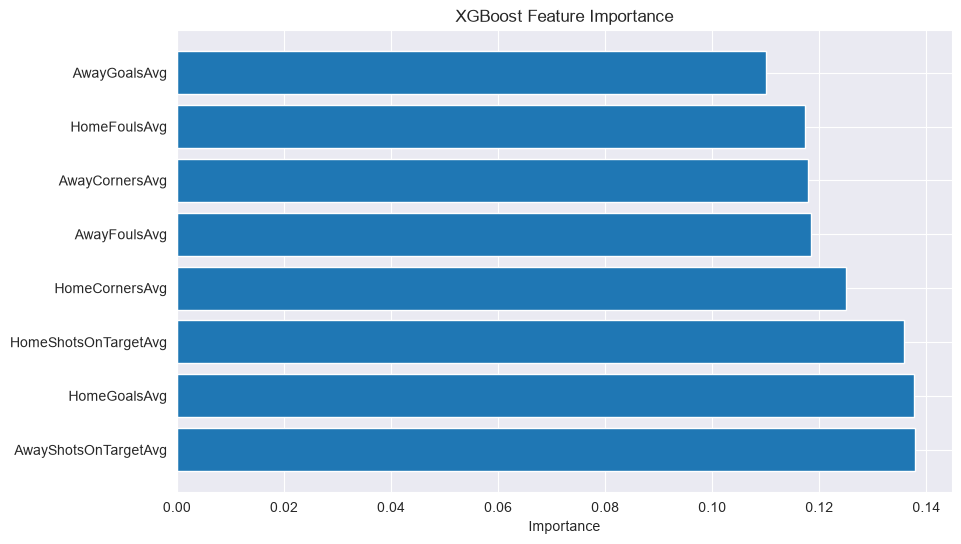

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

#feature loading and encoding
df = pd.read_csv("../data/processed/epl_features.csv")
features = ["HomeGoalsAvg", "AwayGoalsAvg", "HomeShotsOnTargetAvg", "AwayShotsOnTargetAvg", "HomeCornersAvg", "AwayCornersAvg", "HomeFoulsAvg", "AwayFoulsAvg"]
X = df[features]
y = df["FTR"]
encoder = LabelEncoder()
y = encoder.fit_transform(y)

#Model setup
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
#Model training and testing
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: ", accuracy)
print(classification_report(y_test, predictions, zero_division=0))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=encoder.classes_
)

plt.show()

#Feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

#Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()